# Project Proposal - Analyzing Utah State Legislature Policy Trends

### Team Info
* Gabriella Grover, u1387821@utah.edu, u1387821
* Lucy Ballou, u199709@utah.edu, u1399709

## Background Motivation

We're both studying economics with backgrounds in politcal science and history, so this topic naturally appeals to our interests. Additionally, we both plan to pursue careers that use both data science and policy analysis. The Utah Legistlature is generally inaccessible to the average citizen, thanks to the increased use of politcal jargon and (at times sketchy) manuevers. Constituents have a right to know what their elected officials are enacting, but recent sessions have shown that is becoming a harder objective to meet. With our project, we hope to shed some light on some key relationships within the Legistlature and find some helpful indicators on what makes a successful bill.

## Project Objectives

Our primary research questions are:

>"What aspects of a bill most influence a bill's passage? Can you predict the outcome of a bill based on certain bill aspects?"
>
>"Do economic indicators influence the outcomes of bills given a subject matter?"

We want to explore the relationships that affect a bill throughout it's lifecycle. We have the possibility to expand the data to not be just bill pass/fail but can get last location, so we can try to predict how far a bill can go based of various factors. This will require us to do a lot of exploratory analysis to determine what relationships exist/the strongest relations, then using that information for our prediction models.

This project will primarily be done through API requests, so we also want to improve our data acquisition and cleaning skills over the course of this project. 

This project will benefit constituents and policymakers by finding patterns in what bills are being passed, allowing both constituents and policymakers to identify bills they care about and how they might be manipulated in order to get them signed into law.

## Data Description and Acquisition

Our data came primarily from the Utah legislative API (https://le.utah.gov/data/developer.htm). We pulled raw data for over 9,300 bills and their respective characterisitcs from the 2016 to 2026 general sessions. The API is available to the public with the use of a developer token, which we requested and have redacted to follow best practice. For a list of all bill characterstics we pulled, please refer to the 'ut_bills_final' sheet in our data plan Excel sheet.

We also used data from the Federal Reserve Economic Data (https://fred.stlouisfed.org/) to get our economic & demographic indicators. It is a direct download, and is widely used in research publications. We obtained various variables indicating income and socioeconomic status in order to consider the social and political climate in which these bills exist. We also pulled the Consumer Price Index annual average (CPI-AU) to inflation adjust any money appropriated in the bills.

Finally, we used the Wikimedia REST API (https://meta.wikimedia.org/wiki/Special:RestSandbox/wmf-restbase-global) to obtain a historical list of Utah Representatives and Senators, as well as their respective party affiliation. This API is also publicly available, with the [requirement](https://www.mediawiki.org/wiki/API:REST_API/Policies) to include an HTTP User-Agent Header that we included in our request. We pulled the legislator name to reformat into the sponsorID code found in the Legislative data to connect the party to the correct sponsor. However, some sponsorID's were deviations of the regular format (i.e. inclusion of middle initial that was not listed on the Wikipedia page, multiple codes for one legislator), so we had to go in and manually add ~50 sponsorIDs.

**Pulled Variables**

*Utah Legislative Website*

* Bill ID
* Sponsor & Co-Sponsor
* Last Location
* Subjects
* Number of Substitutes
* Committee
* Money Appropriated
* Originating & Final Chamber (House/Senate)
* Session Year

*FRED* (all Utah specific)

* Housing Availablity/Avg Prices
* Unemployment rate/Labor force participation
* Avg Yearly Income
* Yearly Tax Revenue
* Population size/growth
* GDP Growth
* CPI Annual Avg

*Wikipedia REST API*

* Legislator Full Name
* Legislator Party
* Legislator Session

In [2]:
# importing packages
import requests
import pandas as pd
import json
import time
import numpy as np
import re
from bs4 import BeautifulSoup

In [3]:
# # pulling data from the legislative API

# TOKEN = "REDACTED"
# BASE_URL = "https://glen.le.utah.gov/bills"

# # defining sessions (pre-2016 is unavail with API)
# sessions = [
#     "2016GS", "2017GS", "2018GS", "2019GS", "2020GS",
#     "2021GS", "2022GS", "2023GS", "2024GS", "2025GS", "2026GS"
# ]

# # extracting bill numbers
# all_bills = {}

# for session in sessions:
#     url = f"{BASE_URL}/{session}/billlist/{TOKEN}"
#     response = requests.get(url)

#     if response.status_code == 200:
#         try:
#             data = response.json()

#             # handling the fact that some years are formatted as plain lists, some are objects, some are strings
#             if isinstance(data, list):
#                 bill_list = data
#             elif isinstance(data, dict) and "bills" in data:
#                 bill_list = data["bills"]
#             else:
#                 print(f"{session}: Unexpected format")
#                 continue

#             bill_numbers = [bill['number'] for bill in bill_list]
#             all_bills[session] = bill_numbers
#             print(f"{session}: {len(bill_numbers)} bills")
#         except Exception as e:
#             print(f"{session}: Failed - {e}")
#     else:
#         print(f"{session}: ERROR {response.status_code}")

#     time.sleep(1)

# total = sum(len(bills) for bills in all_bills.values())
# print(f"\nTotal bills across sessions: {total}")

# # actual extracting
# def extract_bill_data(session, bill_number, token):
#     url = f"{BASE_URL}/{session}/{bill_number}/{token}"
#     response = requests.get(url)

#     if response.status_code != 200:
#         return None

#     try:
#         data = response.json()
#     except:
#         return None

#     if isinstance(data, dict) and "bill" in data and isinstance(data["bill"], dict):
#         data = data["bill"]

#     if isinstance(data, str):
#         try:
#             data = json.loads(data)
#         except:
#             return None

#     # skip if still not a dict
#     if not isinstance(data, dict):
#         return None

#     is_old_format = "shorttitle" in data

#     if is_old_format:
#         # old format
#         subjects = data.get("subjects", [])

#         # committees from agendas
#         agendas = data.get("agendas", [])
#         committees = list(set(
#             a.get("committee", a.get("committeeName", ""))
#             for a in agendas
#         )) if agendas else []

#         # originating chamber from bill number prefix
#         bill_id = data.get("bill", "")
#         if bill_id.startswith("HB") or bill_id.startswith("HJ"):
#             orig_chamber = "House"
#         elif bill_id.startswith("SB") or bill_id.startswith("SJ"):
#             orig_chamber = "Senate"
#         else:
#             orig_chamber = ""

#         return {
#             "bill_id": bill_id,
#             "short_title": data.get("shorttitle", ""),
#             "sponsor": data.get("sponsor", ""),
#             "co_sponsors": "None",
#             "floor_sponsor": data.get("floorsponsor", ""),
#             "last_action": data.get("lastaction", ""),
#             "last_action_owner": data.get("lastactionowner", ""),
#             "subjects": "; ".join(subjects) if isinstance(subjects, list) else str(subjects),
#             "num_substitutes": 0,
#             "substitute_sponsors": "None",
#             "active_version": data.get("version", ""),
#             "subjects_changed": False,
#             "committees": "; ".join(committees),
#             "money_appropriated": data.get("monies", ""),
#             "originating_chamber": orig_chamber,
#             "final_chamber": "",
#             "sponsor_id": data.get("sponsor", ""),
#             "session_year": session[:4],
#             "session_id": session,
#         }

#     else:
#         # new format
#         versions = data.get("billVersionList", [])

#         # finding and extracting active version for co-sponsors and subjects
#         active_version = None
#         active_version_label = ""
#         for version in versions:
#             if version.get("activeVersion", False):
#                 active_version = version
#                 active_version_label = version.get("billNumber", "")
#                 break
#         if active_version is None and versions:
#             active_version = versions[-1]
#             active_version_label = versions[-1].get("billNumber", "")

#         subjects = []
#         if active_version:
#             subjects = list(set(
#                 s["description"] for s in active_version.get("subjectList", [])
#             ))

#         co_sponsors = []
#         if active_version:
#             co_sponsors = [
#                 cs.get("name", "") for cs in active_version.get("coSponsorList", [])
#             ]

#         # substitute stuff
#         substitutes = [v for v in versions if int(v.get("subVersion", 0)) > 0]
#         num_substitutes = len(substitutes)

#         sub_sponsors = "; ".join(
#             f"{v['billNumber']}: {v.get('versionSponsorName', 'Unknown')}"
#             for v in substitutes
#         )

#         # whether subjects changed across versions?
#         def get_subjects_set(version):
#             return set(s["description"] for s in version.get("subjectList", []))

#         if len(versions) > 1:
#             original_subjects = get_subjects_set(versions[0])
#             subjects_changed = any(
#                 get_subjects_set(v) != original_subjects for v in versions[1:]
#             )
#         else:
#             subjects_changed = False

#         # getting committees from agendaList
#         committees = list(set(
#             a["committeeName"] for a in data.get("agendaList", [])
#         ))

#         # finding original and final chamber from action history
#         originating_chamber = data.get("primeSponsorHouse", "")
#         final_chamber = ""
#         for action in reversed(data.get("actionHistoryList", [])):
#             if action.get("actionClass") in ("H", "S"):
#                 final_chamber = "House" if action["actionClass"] == "H" else "Senate"
#                 break

#         return {
#             "bill_id": data.get("billNumber", ""),
#             "short_title": data.get("shortTitle", ""),
#             "sponsor": data.get("primeSponsorName", ""),
#             "co_sponsors": "; ".join(co_sponsors) if co_sponsors else "None",
#             "floor_sponsor": data.get("floorSponsorName", ""),
#             "last_action": data.get("lastAction", ""),
#             "last_action_owner": data.get("lastActionOwner", ""),
#             "subjects": "; ".join(subjects),
#             "num_substitutes": num_substitutes,
#             "substitute_sponsors": sub_sponsors if sub_sponsors else "None",
#             "active_version": active_version_label,
#             "subjects_changed": subjects_changed,
#             "committees": "; ".join(committees),
#             "money_appropriated": data.get("moniesAppropriated", ""),
#             "originating_chamber": "House" if originating_chamber == "H" else "Senate",
#             "final_chamber": final_chamber,
#             "sponsor_id": data.get("primeSponsor", ""),
#             "session_year": data.get("year", ""),
#             "session_id": data.get("sessionID", ""),
#         }


# # extraction loop
# all_rows = []

# for session, bill_numbers in all_bills.items():
#     print(f"\n--- {session}: {len(bill_numbers)} bills ---")

#     for i, bill_number in enumerate(bill_numbers):
#         result = extract_bill_data(session, bill_number, TOKEN)

#         if result:
#             all_rows.append(result)
#         else:
#             print(f"  Failed: {bill_number}")

#         # progress update every 50 bills
#         if (i + 1) % 50 == 0:
#             print(f"  Processed {i + 1}/{len(bill_numbers)}")

#         time.sleep(1)

#     # save progress after each session
#     df_progress = pd.DataFrame(all_rows)
#     df_progress.to_csv("utah_bills_progress.csv", index=False)
#     print(f"  Saved progress: {len(all_rows)} total rows so far")

# # build dataframe
# df = pd.DataFrame(all_rows)
# df.to_csv("utah_bills_final.csv", index=False)
# print(f"\nFinal dataset: {df.shape[0]} rows, {df.shape[1]} columns")
# print(df.head())


In [4]:
# # pulling party API
# BASE_URL = "https://en.wikipedia.org/api/rest_v1"
# HEADERS = {"User-Agent": "UtahLegislatorResearch/1.0 (gabriellagrover25@gmail.com)"}

# def clean_text(text):
#     return re.sub(r"\[\d+\]", "", text).strip()

# def get_utah_legislature_members(page_title):
#     url = f"{BASE_URL}/page/html/{page_title}"
#     r = requests.get(url, headers=HEADERS)
#     soup = BeautifulSoup(r.text, "html.parser")

#     # Find all tables on the page
#     tables = soup.find_all("table")

#     senate = []
#     house = []

#     for table in tables:
#         headers = [th.get_text(strip=True) for th in table.find_all("th")]

#         # Look for tables that have District, Name, Party columns
#         if "District" in headers and "Name" in headers and "Party" in headers:
#             rows = table.find_all("tr")[1:]  # skip header row
#             members = {}
#             for row in rows:
#                 cols = [clean_text(td.get_text(strip=True)) for td in row.find_all("td")]
#                 if len(cols) >= 3:
#                     members[cols[1]] = cols[2]

#             # Senate has 29 members, House has 75 — use length to tell them apart
#             if len(members) <= 30:
#                 senate = members
#             else:
#                 house = members

#     return senate, house

# senate_big = {}
# house_big = {}

# sessions = ['63rd', '64th', '65th', '66th']

# for sesh in sessions:
#     senate_df, house_df = get_utah_legislature_members(f"{sesh}_Utah_State_Legislature")
#     senate_big[sesh] = senate_df
#     house_big[sesh] = house_df

# rows1 = []
# for session, members in senate_big.items():
#     if not isinstance(members, dict): 
#         continue
#     for name, party in members.items():
#         rows1.append({
#             "session": session,
#             "name":    name,
#             "party":   party
#         })

# rows2 = []
# for session, members in house_big.items():
#     if not isinstance(members, dict):  # skip if it's not a dictionary
#         print(f"Skipping {session} — unexpected type: {type(members)}")
#         continue
#     for name, party in members.items():
#         rows2.append({
#             'session' : session,
#             'name': name,
#             'party': party
#         })

# senate_df = pd.DataFrame(rows1)
# house_df = pd.DataFrame(rows2)

# def get_id(name):
#     match = re.search(r'[A-Z\.](?:\s[A-Z][a-z]+)+', name)
#     if match:
#         pre, first, last = name.split(" ", 2)
#         return (last[:5]+pre[:1]+first[:1]).upper()
    
#     match1 = re.search(r'[A-Z][a-z]+(?:\s[A-Z][a-z]+)', name)
#     if match1:
#         first, last = name.split(" ", 1)
#         return (last[:5]+first[:1]).upper()
        
#     match2 = re.search(r'[A-Z][a-z]+(?:\s[A-Z]\.)(?:\s[A-Z][a-z]+)', name)
#     if match2:
#         first, middle, last = name.split(" ", 2)
#         return (last[:5]+first[:1]+middle[:1]).upper()
        
#     else: return None

# senate_df['id'] = senate_df['name'].apply(get_id)
# house_df['id'] = house_df['name'].apply(get_id)

# senate_df.to_csv('senate_df.csv', index = False)
# house_df.to_csv('house_df.csv', index = False)

# # after this, I had to manually add in the party and representative ID in Excel. I also combined the senate and house reps.

## Ethical Considerations

This project would impact Utah residents, employees of the state legislature, and potentially other state legislatures. We hope it will distill bills filled with political jargon into ordinarily comprehensible language so that normal constituents can follow, as well as encourage their civic engagement via awareness of the policy indicators discovered in our study. However, this information can be used by policymakers to inform their legislative strategy, potentially encouraging them to pass bills only in "proven successful" (via our study) subject areas and leaving other subjects undeveloped (especially for those up for reelection at the time). This information can also be used by malignant lobbying groups to improve their strategy and manipulate policymakers.

## Data Cleaning and Processing

There was not much data cleaning required for the FRED data besides converting the CPI column into an inflation-adjusting multiplier. Using 2025 as the base year, we saved all converted CPI numbers in a new column entitled "inflation". We then selected three economic indicators - yearly poverty rate, real GDP, and rental vacancy rate - to include in our final analysis. We chose these variables because they capture three distinct areas of the economy: the poverty rate reflects the impact of the economy on households, real GDP captures the overal economic health, and the rental vacancy rate the housing market and affordability (a hot topic in the legislature since 2020).

After reviewing the legislative data, we decided to exclude any and all types of resolutions. Bills are proposals that, once passed through the entire legislative process and signed by the Governor, become law. Resolutions, on the other hand, do not; they typically serve as statements made by the legislature expressing an opinion, honoring an individual, or manage internal processes. They also do not follow the same legislative process as bills since they do not need to be heard by the opposite chamber to pass. Thus, the difference in impact and process justifies the exclusion of the resolutions. We also decided to exclude bills that did not have a floor sponsor, since Utah requires all bills to have a floor sponsor to be an actionable bill. Since all bills that do not have a floor sponsor will fail, they will have an outsized influence on bill outcome and skew our models. 

After removing these bills, our dataset now included 6,730 bills. From there, we began deriving usable variables for our analysis from the bill data. First, we created a binary "passed" variable, where 1 meant the bill was signed into law and 0 otherwise. We also created different binary coded stage variables that capture the intermediate stage locations a bill passed through (see the code for more in-depth description of each stage). Next, we got the primary subject group of a bill by assigning a 1 to the most frequent subject type in the bill's list of relevant subjects. We had 870 different subjects in the dataset, so we used a dictionary assignment to group the bills into a larger subject group, resulting in 22 subject groups overall. After, we created one-hot variables of cosponsor, money appropriated, and committee status, where 1 is the bill had at least one cosponsor, committee, etc. associated with it and 0 otherwise. We also created a binary "chamber" variable where 1 meant the bill's originating chamber was the House and 0 the Senate. We then extracted and summed the amount of money appropriated in each bill, then inflation adjusted and log transformed the value to give is the log real money appropriated. We log transformed the values due to the heavy right skew of the data (if money was appropriated, it was typically in the millions of dollars, but the majority of bills had zero dollars appropriated). Finally, we stitched the three economic indicators to the dataframe.


Finally, we used a matching function to match the bill's sponsorID to the sponsorID in the party CSV to get the bill sponsor's party, then binary coded the variable to be 1 if the sponsor was Republican and 0 otherwise (both Democratic and Utah Forward parties were present in the dataset). We then saved the final dataset as a CSV.

In [5]:
# stitching FRED data
df_fred = pd.read_csv('FREDdata.csv')
df_fred['inflation'] = df_fred['cpi'].map(lambda x: 321.943/x)
df_fred

,observation_date,bach_or_higher,umemployment_rate,med_hh_income,poverty_rate,homeownership_rate,gdp,resident_population,real_gdp,rental_vacancy_rate,lfp,cpi,inflation
0,2010,29.3,8.3,56700.0,13.3,72.5,118296.3,2775.413,133739.1,7.2,68.83,218.056,1.476423
1,2011,29.7,7.2,55490.0,13.6,71.4,125137.8,2814.797,138301.1,6.4,67.60,224.939,1.431246
2,2012,30.7,4.8,58340.0,13.0,71.1,129431.4,2854.146,140622.5,7.7,66.73,229.594,1.402227
3,2013,31.3,4.2,61050.0,12.6,70.9,135344.3,2898.773,145026.9,6.7,67.29,232.957,1.381985
4,2014,31.1,3.6,63380.0,11.8,70.9,142627.7,2938.327,150076.3,8.6,67.59,236.736,1.359924
5,2015,31.8,3.5,66260.0,11.2,69.9,149762.1,2983.626,155431.5,5.1,68.04,237.017,1.358312
6,2016,32.6,3.3,67480.0,10.2,71.3,159330.6,3044.241,162528.2,5.7,68.50,240.007,1.341390
7,2017,34.6,3.1,69790.0,9.7,71.0,172075.0,3103.540,172075.0,6.2,68.85,245.120,1.313410
8,2018,34.9,2.9,77070.0,9.1,72.2,186805.7,3155.153,182106.0,5.4,68.54,251.107,1.282095
9,2019,34.8,2.5,84520.0,8.8,71.9,201312.2,3203.383,192760.6,3.8,68.50,255.657,1.259277


In [6]:
# loading in ut_bills.csv
ut_bills = pd.read_csv('utah_bills_final.csv')


# removing all resolutions (simple, joint, concurrent) to have dataset of only laws
laws = ['SJR', 'HJR', 'SCR', 'HCR', 'SR0', 'HR0']
df_bills = ut_bills.loc[~ut_bills['bill_id'].str[:3].isin(laws)].copy().reset_index(drop=True)
print(df_bills.shape, ut_bills.shape)


# cleaning NAs of subjects, committees, cosponsors, floor_sponsor, money_approrpiated
na_names = ['subjects', 'committees','co_sponsors', 'floor_sponsor', 'money_appropriated']
df_bills[na_names] = df_bills[na_names].replace({np.nan:'None'})


# making lists of all action types

location0 = ['House/ filed', 'Senate/ filed', ''] # died in starting chamber (committee, house or senate)

location1 = ['House/ received from Senate', 
            'Senate/ received from House',
            'Senate/ 2nd Reading Calendar to Rules'] # reached non-originating chamber

location2 = ['Governor Line Item Veto',
            'Governor Vetoed',
            'Senate/ strike enacting clause',
            'Bill Failed Review - Returned to House'] # reached gov office (or post-Legislature)

location3 = ['LFA/ fiscal note publicly available',
            'LFA/ fiscal note sent to sponsor',
            'Became Law w/o Governor Signature',
            'Senate/ to Governor',
            'House/ to Governor',
            'House/ to Lieutenant Governor',
            'Senate/ to Lieutenant Governor',
            'Governor Declined to Sign',
            'Senate/ received enrolled bill from Printing',
            'House/ enrolled bill to Printing',
            'Senate/ enrolled bill to Printing',
            'Governor Signed'] # final location (aka passed)

# converting 'last_action' to ordinal range 'final_location' (god bless numpy select)
conditions = [df_bills['last_action'].isin(location0),
              df_bills['last_action'].isin(location1),
              df_bills['last_action'].isin(location2),
              df_bills['last_action'].isin(location3)]
choices = [0,1,2,3]

df_bills['location_stage'] = np.select(conditions, choices)

# converting 'last_action' to 'passed' binary variable
df_bills['passed'] = df_bills['last_action'].map(lambda x: 1 if x in location3 else 0)




# grouping our 870 subjects (yes, 870) into 21 groups
subject_to_group = {
    # Criminal Justice
    'Crimes': 'crim_justice', 'Offenses': 'crim_justice', 'Criminal Procedure': 'crim_justice',
    'Criminal Code': 'crim_justice', 'Criminal Conduct': 'crim_justice', 'Criminal Identification': 'crim_justice',
    'Sentencing': 'crim_justice', 'Parole': 'crim_justice', 'Probation': 'crim_justice',
    'Expungement': 'crim_justice', 'Juvenile Justice': 'crim_justice', 'Juvenile Justice Services': 'crim_justice',
    'Peace Officers': 'crim_justice', 'Peace Officer': 'crim_justice', 'Courts': 'crim_justice',
    'Arrest and Detention': 'crim_justice', 'Bail\\Pretrial Detention': 'crim_justice',
    'Bail/Pretrial Detention': 'crim_justice', 'Plea Agreements': 'crim_justice',
    'Restitution': 'crim_justice', 'Recidivism': 'crim_justice', 'Homicide': 'crim_justice',
    'Theft': 'crim_justice', 'Assault and Battery': 'crim_justice', 'Vandalism': 'crim_justice',
    'Kidnapping': 'crim_justice', 'Prostitution': 'crim_justice', 'Gambling': 'crim_justice',
    'Gangs': 'crim_justice', 'Human Trafficking': 'crim_justice', 'Sexual Offenses': 'crim_justice',
    'Sex Offender Registry': 'crim_justice', 'Offender Registries': 'crim_justice',
    'Death Penalty': 'crim_justice', 'Insanity Defense': 'crim_justice',
    'Insanity Defense/Competency': 'crim_justice', 'Competency': 'crim_justice',
    'Forfeiture Procedure': 'crim_justice', 'Search and Seizure': 'crim_justice',
    'Protective Orders': 'crim_justice', 'Protective Orders/Stalking Injuctions': 'crim_justice',
    'Bureau of Criminal Identification': 'crim_justice', 'Bureau of Criminal Investigation': 'crim_justice',
    'Commission on Criminal and Juvenile Justice': 'crim_justice', 'Sentencing Commission': 'crim_justice',
    'Inmates': 'crim_justice', 'Correctional Facilities': 'crim_justice',
    'Department of Corrections': 'crim_justice', 'Youth Corrections': 'crim_justice',
    'Juvenile Records': 'crim_justice', 'Code of Criminal Procedure': 'crim_justice',
    'Board of Pardons and Parole': 'crim_justice', 'Indigent Defense': 'crim_justice',
    'Indigent Counsel': 'crim_justice', 'Drug Court': 'crim_justice',
    'Law Enforcement and Criminal Justice': 'crim_justice', 'Peace Officer Standards and Training': 'crim_justice',
    'Utah Highway Patrol': 'crim_justice', 'Fraud': 'crim_justice',
    'Punishments': 'crim_justice', 'Punishment': 'crim_justice',
    'Self Defense': 'crim_justice', 'Defenses': 'crim_justice',
    'Weapons': 'crim_justice', 'Graffiti': 'crim_justice',

    # Education K-12
    'K-12 Education': 'ed_k12', 'School Finance': 'ed_k12', 'School Safety': 'ed_k12',
    'School Districts': 'ed_k12', 'Special Education': 'ed_k12',
    'Standards and Curriculum': 'ed_k12', 'School Accountability': 'ed_k12',
    'School Personnel': 'ed_k12', 'School Fees': 'ed_k12',
    'School Facilities': 'ed_k12', 'Student Assessment': 'ed_k12',
    'Student Discipline': 'ed_k12', 'Student Privacy': 'ed_k12',
    'Student Health and Safety': 'ed_k12', 'Student health and safety': 'ed_k12',
    'Local Boards of Education': 'ed_k12', 'State Board of Education': 'ed_k12',
    'Local Education Agencies (LEAs)': 'ed_k12', 'Charter Schools': 'ed_k12',
    'Home Schooling': 'ed_k12', 'Prekindergarten': 'ed_k12',
    'School Community Councils': 'ed_k12', 'School community councils': 'ed_k12',
    'State School Funding Distribution': 'ed_k12', 'Public Education': 'ed_k12',
    'Public Education Data and Reporting': 'ed_k12', 'Education Grant Programs': 'ed_k12',
    'Competency in Education': 'ed_k12', 'Strategic Planning for Education': 'ed_k12',
    'School and Institutional Trust Fund Office': 'ed_k12',
    'School and Institutional Trust Land Administration': 'ed_k12',
    'Online Learning and/or Technology': 'ed_k12', 'Educational Telecommunications': 'ed_k12',
    'Applied Technology Education': 'ed_k12', 'Technical Colleges': 'ed_k12',
    'Campus Safety': 'ed_k12', 'On-campus Speech': 'ed_k12',

    # Higher Education
    'Higher Education': 'higher_ed', 'Colleges and Universities': 'higher_ed',
    'Utah Board of Higher Education': 'higher_ed', 'State Board of Regents': 'higher_ed',
    'Utah System of Higher Education': 'higher_ed', 'Scholarships and Financial Aid': 'higher_ed',
    'Concurrent Enrollment': 'higher_ed', 'Nontraditional Students': 'higher_ed',
    'Nontraditional students': 'higher_ed', 'Higher Education Students': 'higher_ed',
    'Performance Funding': 'higher_ed', 'Utech Board of Trustees': 'higher_ed',
    'Utah Education Savings Plan': 'higher_ed',

    # Health Care
    'Public Health': 'health_care', 'Mental Health': 'health_care', 'Medicaid': 'health_care',
    'Medicare': 'health_care', 'Health Insurance': 'health_care', 'Hospitals': 'health_care',
    'Telehealth': 'health_care', 'Substance Abuse': 'health_care', 'Substance Abuse and Mental Health': 'health_care',
    'Substance Use Disorder Treatment': 'health_care', 'Opioids': 'health_care',
    'Medical Cannabis': 'health_care', 'Pharmaceuticals': 'health_care', 'Pharmacies': 'health_care',
    'Pharmacists': 'health_care', 'Pharmacy Benefit Managers': 'health_care',
    'Health Care': 'health_care', 'Health Care Facilities': 'health_care',
    'Health Care Professionals': 'health_care', 'Health Care Providers': 'health_care',
    'Health Care Data and Informatics': 'health_care', 'Health Care Statistics': 'health_care',
    'Health Benefits and Claims': 'health_care', 'Benefits/Claims, Health': 'health_care',
    'Health': 'health_care', 'Health and Human Services': 'health_care',
    'Department of Health': 'health_care', 'Department of Health and Human Services': 'health_care',
    'Diseases': 'health_care', 'Disease Control and Prevention': 'health_care',
    'Diseases Control and Prevention': 'health_care', 'Immunizations': 'health_care',
    'Maternal and Child Health': 'health_care', 'Family Health and Preparedness': 'health_care',
    'Mental Health Facilities': 'health_care', 'Mental Health Professional': 'health_care',
    'Mental Health Professionals': 'health_care', 'Local Mental Health Authorities': 'health_care',
    'Local Substance Abuse Authorities': 'health_care', 'Suicide': 'health_care',
    'Nursing Homes': 'health_care', 'Skilled Nursing Facilities': 'health_care',
    'Ambulatory Surgical Centers': 'health_care', 'Community Health Clinics': 'health_care',
    'Utah State Hospital': 'health_care', 'Utah State Developmental Center': 'health_care',
    'Facility Licensing, Certification, and Resident Assessment': 'health_care',
    'Health Facility Administrators': 'health_care', 'Physicians and Surgeons': 'health_care',
    'Osteopathic Physicians and Surgeons': 'health_care', 'Physician Assistants': 'health_care',
    'Nurses': 'health_care', 'Dentists and Dental Hygienists': 'health_care',
    'Optometrists': 'health_care', 'Psychologists': 'health_care',
    'Physical Therapists': 'health_care', 'Occupational Therapists': 'health_care',
    'Speech-Language Pathologists and Audiologists': 'health_care', 'Respiratory Care Providers': 'health_care',
    'Midwives': 'health_care', 'Acupuncturists': 'health_care', 'Naturopathic Physicians': 'health_care',
    'Chiropractic Physicians': 'health_care', 'Podiatric Physicians': 'health_care',
    'Massage Therapists': 'health_care', 'Hearing Instrument Specialists': 'health_care',
    'Radiologic Technologists, Assistants, and Technicians': 'health_care',
    'Dietitians': 'health_care', 'Genetic Counselors': 'health_care',
    'Athletic Trainers': 'health_care', 'Medical Records': 'health_care',
    'Medical Malpractice': 'health_care', 'Medical Examiner': 'health_care',
    'Medical Fees and Service for Employment': 'health_care',
    'Medical Assistance Programs': 'health_care', 'Advance Health Care Directive': 'health_care',
    'Civil Commitment': 'health_care', 'Abortion': 'health_care',
    'Electronic Cigarettes': 'health_care', 'Tobacco': 'health_care',
    'Tobacco and Other Nicotine Products': 'health_care', 'Alcohol': 'health_care',
    'Alcoholic Beverages': 'health_care', 'Alcoholic Beverage Control': 'health_care',
    'Alcoholic Beverage Control Commission': 'health_care',
    'Department of Alcoholic Beverage Control': 'health_care',
    'Department of Alcoholic Beverage Services': 'health_care',
    'Drug and Alcohol Testing': 'health_care', 'Drugs and Alcohol, Workplace': 'health_care',
    'Controlled Substances': 'health_care', 'Controlled Substances Database': 'health_care',
    'Public Health Laboratory': 'health_care', 'Vital Statistics': 'health_care',
    'Emergency Medical Services': 'health_care', 'Emergency Medical Services and Preparedness': 'health_care',
    'Rural Health': 'health_care', 'Children\'s Health Insurance Program': 'health_care',
    'Rehabilitation Services': 'health_care', 'Adult Protective Services': 'health_care',
    'Long-term Care Ombudsman': 'health_care', 'Aging and Adult Services': 'health_care',
    'Aging Services': 'health_care', 'Insurance, Health': 'health_care',
    'Commercial Health Insurance\\Managed Care Contracts': 'health_care',
    'Public Employees\' Health Program': 'health_care',

    # Environment & Natural Resources
    'Air Quality': 'env_nr', 'Water Quality': 'env_nr',
    'Water': 'env_nr', 'Water Rights': 'env_nr',
    'Water Rights - Const. Art. XVII': 'env_nr',
    'Water Conservation': 'env_nr', 'Water and Irrigation': 'env_nr',
    'Water Utilities, Irrigation, and Sewer': 'env_nr',
    'Drinking Water': 'env_nr', 'Great Salt Lake': 'env_nr',
    'Utah Lake': 'env_nr', 'Mining': 'env_nr',
    'Mines and Mining': 'env_nr', 'Forestry and Fire': 'env_nr',
    'Forestry, Fire, and State Lands': 'env_nr',
    'Forests': 'env_nr', 'Wildlife': 'env_nr',
    'Environmental Quality': 'env_nr',
    'Environmental Response and Remediation': 'env_nr',
    'Department of Environmental Quality': 'env_nr',
    'Environment': 'env_nr', 'Natural Resources': 'env_nr',
    'Department of Natural Resources': 'env_nr',
    'Solid Waste': 'env_nr', 'Waste': 'env_nr',
    'Recycling': 'env_nr', 'Hazardous Materials': 'env_nr',
    'Hazardous Substances': 'env_nr',
    'Hazardous Materials Transportation': 'env_nr',
    'Underground Storage Tanks': 'env_nr',
    'Asbestos': 'env_nr', 'Emissions Control': 'env_nr',
    'Air': 'env_nr', 'Radiation': 'env_nr',
    'Pesticide & Pest Control': 'env_nr',
    'Pesticide and Pest Control': 'env_nr',
    'Reclamation': 'env_nr', 'Conservation District': 'env_nr',
    'Conservation Districts': 'env_nr',
    'State Lands': 'env_nr', 'Sovereign Lands': 'env_nr',
    'Trust Lands': 'env_nr', 'Public Lands': 'env_nr',
    'Geological Survey': 'env_nr', 'Oil and Gas': 'env_nr',
    'Fossil Fuels': 'env_nr', 'Natural Gas': 'env_nr',
    'Dams and Canals': 'env_nr', 'Weeds': 'env_nr',
    'Litter': 'env_nr', 'Noise Abatement': 'env_nr',
    'West Traverse Sentinel Landscape': 'env_nr',
    'Animal Health': 'env_nr', 'Animals': 'env_nr',

    # Transportation
    'Transportation': 'transpo', 'Motor Vehicles': 'transpo',
    'Roads/Highways': 'transpo', 'Highways': 'transpo',
    'Public Transit': 'transpo', 'Public Transit Districts': 'transpo',
    'Railroads': 'transpo', 'Bicycles': 'transpo',
    'Autonomous Vehicles': 'transpo', 'Aeronautics': 'transpo',
    'Airports': 'transpo', 'Boating': 'transpo',
    'Motor Carrier Regulation': 'transpo', 'Commercial Motor Vehicle Regulation': 'transpo',
    'Commercial Driver License (CDL)': 'transpo', 'Driver License': 'transpo',
    'Vehicle Registration': 'transpo', 'Motor Vehicle Insurance': 'transpo',
    'Motor Vehicle Equipment': 'transpo', 'Motor Vehicle Coverings': 'transpo',
    'Motor Vehicle Size Limits': 'transpo', 'Size Limits, Motor Vehicles': 'transpo',
    'Safety Inspection, Motor Vehicles': 'transpo', 'Vehicle Safety Equipment': 'transpo',
    'Off-highway Vehicles': 'transpo', 'Motorcycles': 'transpo',
    'Tow Trucks': 'transpo', 'Towing': 'transpo',
    'Traffic Violations': 'transpo', 'Driving Under the Influence (DUI)': 'transpo',
    'Seat Belt Laws': 'transpo', 'Seat Belts': 'transpo',
    'Helmets': 'transpo', 'Pedestrian Safety': 'transpo',
    'Speed Limits': 'transpo', 'Photo Radar': 'transpo',
    'Transportation Related Fees': 'transpo', 'Transportation Funding': 'transpo',
    'Transportation Fund': 'transpo', 'Transportation Commission': 'transpo',
    'Department of Transportation': 'transpo',
    'Transportation Investment Fund of 2005': 'transpo',
    'Transit Transportation Investment Fund': 'transpo',
    'Active Transportation Investment Fund': 'transpo',
    'Rural Transportation Investment Fund': 'transpo',
    'Active Transportation': 'transpo', 'Congestion Management': 'transpo',
    'Right of Way': 'transpo', 'License Plates': 'transpo',
    'Registration and Registration Fees': 'transpo',
    'Division of Motor Vehicles': 'transpo', 'Ports of Entry': 'transpo',
    'Unmanned Aircraft': 'transpo', 'Ridesharing and Shared Mobility': 'transpo',
    'Transportation Network Company': 'transpo',
    'Heber Valley Historic Railroad Authority': 'transpo',
    'Utah State Railroad Museum Authority': 'transpo',
    'Equipment, Motor Vehicles': 'transpo', 'Trails': 'transpo',

    # Elections & Government Operations
    'Elections': 'elect_gov', 'Election Law': 'elect_gov',
    'Election Administration': 'elect_gov', 'Voting and Voter Registration': 'elect_gov',
    'Voter Registration': 'elect_gov', 'Campaign Finance': 'elect_gov',
    'Redistricting': 'elect_gov', 'Political Parties': 'elect_gov',
    'Initiatives': 'elect_gov', 'Referenda': 'elect_gov',
    'Initiatives / Referendums': 'elect_gov', 'Initiatives \\ Referendums': 'elect_gov',
    'Legislative Operations': 'elect_gov', 'Legislative Organization': 'elect_gov',
    'Legislature': 'elect_gov', 'Legislative Staff Offices': 'elect_gov',
    'Legislative Affairs': 'elect_gov', 'Legislative Committees and Task Forces': 'elect_gov',
    'Committees, Legislative': 'elect_gov', 'Legislative Employees and Compensation': 'elect_gov',
    'Employees and Compensation, Legislative': 'elect_gov',
    'Legislative Publications': 'elect_gov', 'Legislative Oversight of Administrative Rules': 'elect_gov',
    'Legislative Water Development Commission': 'elect_gov',
    'Administrative Rules': 'elect_gov', 'Administrative Rulemaking': 'elect_gov',
    'Administrative Rulemaking and Procedures': 'elect_gov',
    'Administrative Law': 'elect_gov', 'Administrative Law Judges': 'elect_gov',
    'Administrative Procedures': 'elect_gov', 'Administrative Services': 'elect_gov',
    'Rulemaking Procedures': 'elect_gov', 'New Rulemaking Authority': 'elect_gov',
    'Office of Administrative Rules': 'elect_gov',
    'Judicial Review of Administrative Rules': 'elect_gov',
    'Judicial Review of State Agency Adjudicative Proceedings': 'elect_gov',
    'State Agency Adjudicative Proceedings': 'elect_gov',
    'State Agency Review of Adjudicative Proceedings': 'elect_gov',
    'Governor': 'elect_gov', 'Lieutenant Governor': 'elect_gov',
    'Attorney General': 'elect_gov', 'State Auditor': 'elect_gov',
    'State Treasurer': 'elect_gov', 'Constitutional Officers': 'elect_gov',
    'Elected Official': 'elect_gov', 'Public Officers': 'elect_gov',
    'County Officers': 'elect_gov', 'Municipal Officers': 'elect_gov',
    'Ethics': 'elect_gov', 'Conflicts of Interest': 'elect_gov',
    'Lobbying': 'elect_gov', 'Government Records': 'elect_gov',
    'Public Meetings': 'elect_gov', 'Open and Public Meetings': 'elect_gov',
    'Governance': 'elect_gov', 'Federalism': 'elect_gov',
    'Federal Government': 'elect_gov', 'Interlocal Cooperation': 'elect_gov',
    'Interlocal Agreements': 'elect_gov', 'Interlocal Entities': 'elect_gov',
    'Interlocal Cooperation Entities': 'elect_gov',
    'Task Force / Committees': 'elect_gov', 'Boards and Committees': 'elect_gov',
    'State Boards, Commissions, and Councils': 'elect_gov',
    'Revisor Legislation': 'elect_gov', 'Recodification': 'elect_gov',
    'Statutory Construction': 'elect_gov', 'Uniform Laws': 'elect_gov',
    'Resolutions': 'elect_gov', 'Resolutions, Rules': 'elect_gov',
    'Sunset Legislation': 'elect_gov', 'Sunsets and Repealers': 'elect_gov',
    'Boxcar Legislation': 'elect_gov', 'State Affairs in General': 'elect_gov',
    'Publications': 'elect_gov', 'Publications and Broadcasting': 'elect_gov',
    'Official Notices': 'elect_gov', 'Notice Requirements': 'elect_gov',
    'Archives': 'elect_gov', 'Archives and Records': 'elect_gov',
    'History': 'elect_gov', 'Capitol Hill': 'elect_gov',
    'State Symbols and Designations': 'elect_gov',
    'Flag (American)': 'elect_gov', 'Constitution': 'elect_gov',
    'Utah Constitutional Amendments': 'elect_gov',
    'Independent Entities': 'elect_gov',
    'Retirement and Independent State Entities': 'elect_gov','Governmental Immunity': 'elect_gov',
    'Tribal Nations Within Utah': 'elect_gov','Division of Indian Affairs': 'elect_gov',
    'Repatriation of Native American Remains': 'elect_gov',

    # Taxation & Finance
    'Income Tax': 'tax_fin', 'Individual Income Tax': 'tax_fin',
    'Sales Tax Exemptions': 'tax_fin', 'Sales and Use Tax': 'tax_fin',
    'Property Tax': 'tax_fin', 'Property Tax Collection': 'tax_fin',
    'Property Tax Relief': 'tax_fin', 'Farmland Assessment': 'tax_fin',
    'Assessment and Equalization': 'tax_fin', 'Truth in Taxation': 'tax_fin',
    'Tax Credits': 'tax_fin', 'Tax Increment Financing': 'tax_fin',
    'Excise Taxes': 'tax_fin', 'Corporate Tax': 'tax_fin',
    'Severance Tax': 'tax_fin', 'Privilege Tax': 'tax_fin',
    'Gross Receipts': 'tax_fin', 'Motor Fuel and Special Fuel Taxes': 'tax_fin',
    'Cigarette and Tobacco Taxes': 'tax_fin', 'Beer Tax': 'tax_fin',
    'Local Option Sales Taxes': 'tax_fin', 'Local Taxation and Fees': 'tax_fin',
    'Tribal Tax Issues': 'tax_fin', 'Revenue': 'tax_fin',
    'Revenue and Taxation': 'tax_fin', 'State Tax Commission': 'tax_fin',
    'Appropriations': 'tax_fin', 'Budgeting': 'tax_fin',
    'Public Budgeting': 'tax_fin', 'Fiscal Procedures': 'tax_fin',
    'Finance': 'tax_fin', 'Division of Finance': 'tax_fin',
    'Bonds': 'tax_fin', 'Public Bonds': 'tax_fin',
    'Public Funds and Accounts': 'tax_fin', 'Fees': 'tax_fin',
    'Uniform Fees': 'tax_fin', 'Fines': 'tax_fin',
    'Local Expenditures': 'tax_fin', 'Unclaimed Property': 'tax_fin',
    'Mineral Lease Funds': 'tax_fin', 'Permanent Community Impact Fund': 'tax_fin',
    'Impact Fees': 'tax_fin', 'Assessment Area': 'tax_fin',
    'Energy Assessment Area': 'tax_fin', 'County and Municipal Finance': 'tax_fin',
    'State Infrastructure Bank': 'tax_fin', 'Utah Capital Investment Corporation': 'tax_fin',
    'Risk Management Fund': 'tax_fin', 'Division of Risk Management': 'tax_fin',
    'Procurement': 'tax_fin', 'Government Purchasing': 'tax_fin',
    'Division of Purchasing and General Services': 'tax_fin',

    # Labor & Employment
    'Labor': 'labor_ee', 'Labor & Employment': 'labor_ee',
    'Labor and Employment': 'labor_ee', 'Labor Commission': 'labor_ee',
    'Labor Disputes': 'labor_ee', 'Labor Organizations': 'labor_ee',
    'Working Conditions': 'labor_ee', 'Workplace Safety and Health': 'labor_ee',
    'Occupational Safety and Health (OSHA)': 'labor_ee',
    'Occupational Disease': 'labor_ee', 'Industrial Accident': 'labor_ee',
    'Workers\' Compensation': 'labor_ee', 'Unemployment Insurance': 'labor_ee',
    'Wages': 'labor_ee', 'Right to Work': 'labor_ee',
    'Collective Bargaining': 'labor_ee', 'Unfair Labor Practices': 'labor_ee',
    'Employment Agencies': 'labor_ee', 'Employment of Minors': 'labor_ee',
    'Apprenticeship Training': 'labor_ee', 'Job Training': 'labor_ee',
    'Workforce Services': 'labor_ee', 'Department of Workforce Services': 'labor_ee',
    'Department of Human Resource Management': 'labor_ee',
    'Division of Human Resource Management': 'labor_ee',
    'State Officers and Employees': 'labor_ee',
    'Local Government Employees': 'labor_ee',
    'Sexual Harassment': 'labor_ee', 'Antidiscrimination': 'labor_ee',

    # Family & Social Services
    'Child Welfare': 'fam_ss', 'Foster Care': 'fam_ss',
    'Adoption': 'fam_ss', 'Child Custody/Parent Time': 'fam_ss',
    'Child Custody \\ Parent-Time': 'fam_ss',
    'Child Support': 'fam_ss', 'Child Care': 'fam_ss',
    'Child Care Licensing': 'fam_ss', 'Child \\ Day Care': 'fam_ss',
    'Child \\ Day Care Licensing': 'fam_ss',
    'Child Development': 'fam_ss', 'Children': 'fam_ss',
    'Minors': 'fam_ss', 'Juveniles': 'fam_ss',
    'Domestic Violence': 'fam_ss', 'Family': 'fam_ss',
    'Marriage / Divorce': 'fam_ss', 'Marriage/Divorce': 'fam_ss',
    'Parentage': 'fam_ss', 'Grandparents': 'fam_ss',
    'Parental Defense': 'fam_ss', 'Guardian Ad Litem': 'fam_ss',
    'Guardianship/Conservatorship': 'fam_ss', 'Guardians': 'fam_ss',
    'Conservators': 'fam_ss', 'Emancipation': 'fam_ss',
    'Homelessness': 'fam_ss', 'Homeless Persons': 'fam_ss',
    'Intergenerational Poverty': 'fam_ss', 'Public Assistance': 'fam_ss',
    'Human Services': 'fam_ss', 'Human Services Programs': 'fam_ss',
    'Human Services Licensure': 'fam_ss', 'Human Services Facilities': 'fam_ss',
    'Department of Human Services': 'fam_ss',
    'Adult Services': 'fam_ss', 'Elderly': 'fam_ss',
    'Division of Child and Family Services': 'fam_ss',
    'Office of Recovery Services': 'fam_ss',
    'Abuse, Neglect, Exploitation of Vulnerable Adults': 'fam_ss',
    'Abuse, Neglect, or Exploitation of Vulnerable Adults': 'fam_ss',
    'Abuse, Neglect, or Dependency': 'fam_ss',
    'Victims': 'fam_ss', 'Victims\' Rights': 'fam_ss',
    'Disabilities': 'fam_ss', 'Services for People with Disabilities': 'fam_ss',
    'Blind Persons': 'fam_ss', 'Blind and Visually-impaired Services': 'fam_ss',
    'Utah Schools for the Deaf and the Blind': 'fam_ss',
    'Deaf and Hard of Hearing': 'fam_ss',
    'Deaf and Hard of Hearing Services': 'fam_ss',
    'Refugees': 'fam_ss', 'Immigrants \\ Immigration': 'fam_ss',
    'Immigration': 'fam_ss', 'Indian Affairs': 'fam_ss',
    'Multicultural Affairs': 'fam_ss',
    'Food Security': 'fam_ss', 'Fatality Reports': 'fam_ss',
    'Death': 'fam_ss', 'Licensure, Human Services Programs': 'fam_ss',

    # Housing & Land Use
    'Affordable Housing': 'house_land_use', 'Housing': 'house_land_use',
    'Housing and Community Development': 'house_land_use',
    'Utah Housing Corporation': 'house_land_use', 'Planning and Zoning': 'house_land_use',
    'Real Estate': 'house_land_use', 'Real Property': 'house_land_use',
    'Landlord - Tenant': 'house_land_use', 'Landlord -- Tenant': 'house_land_use',
    'Land Use': 'house_land_use', 'Condominiums': 'house_land_use',
    'Community/Condominium Associations (HOAs)': 'house_land_use',
    'Eminent Domain': 'house_land_use',
    'Eminent Domain (Government Land Take Over)': 'house_land_use',
    'Annexation': 'house_land_use', 'Municipal Boundaries': 'house_land_use',
    'Local Government Boundaries': 'house_land_use',
    'Incorporation': 'house_land_use', 'Unincorporated Areas': 'house_land_use',
    'Fair Housing': 'house_land_use', 'Easements': 'house_land_use',
    'Property Conveyance': 'house_land_use', 'Mortgage': 'house_land_use',
    'Mortgage/Deed of Trust': 'house_land_use', 'Appraisals': 'house_land_use',
    'Title and Escrow': 'house_land_use', 'Liens': 'house_land_use',
    'Construction': 'house_land_use', 'Construction Industries': 'house_land_use',
    'Construction and Fire Codes': 'house_land_use',
    'State Buildings': 'house_land_use', 'State Facilities': 'house_land_use',
    'Facilities, Construction, and Management': 'house_land_use',
    'Local Building Authority': 'house_land_use',
    'Community Development': 'house_land_use',
    'Community Development and Renewal Agencies': 'house_land_use',
    'Community Reinvestment Agencies': 'house_land_use',

    # Business & Commerce
    'Business': 'bus_comm', 'Commerce and Trade': 'bus_comm',
    'commerce': 'bus_comm', 'Corporations': 'bus_comm',
    'Limited Liability Company': 'bus_comm', 'Limited Liability Companies': 'bus_comm',
    'Partnerships': 'bus_comm', 'Business Entities': 'bus_comm',
    'Business Licensing': 'bus_comm', 'Business Development': 'bus_comm',
    'Contracts': 'bus_comm', 'Contracts and Obligations': 'bus_comm',
    'Consumer Protection': 'bus_comm', 'Consumer Credit': 'bus_comm',
    'Credit': 'bus_comm', 'Antitrust': 'bus_comm',
    'Antitrust Law': 'bus_comm', 'Insurance': 'bus_comm',
    'Insurance Department': 'bus_comm', 'Department of Insurance': 'bus_comm',
    'Property and Casualty Insurance': 'bus_comm',
    'Life Insurance and Annuities': 'bus_comm',
    'Motor Vehicle Insurance': 'bus_comm',
    'Occupational and Professional Licensing': 'bus_comm',
    'Division of Professional Licensing': 'bus_comm',
    'Office of Licensing': 'bus_comm',
    'Office of Licensing and Background Checks': 'bus_comm',
    'Occupations and Professions': 'bus_comm',
    'Securities': 'bus_comm', 'Bankruptcy': 'bus_comm',
    'Franchise': 'bus_comm', 'Franchises': 'bus_comm',
    'Retail Trade': 'bus_comm', 'Manufacturing': 'bus_comm',
    'Advertising': 'bus_comm', 'Trademarks': 'bus_comm',
    'International Trade': 'bus_comm', 'Tourism': 'bus_comm',
    'Department of Commerce': 'bus_comm',
    'Department of Financial Institutions': 'bus_comm',
    'Financial Institutions': 'bus_comm', 'Banks': 'bus_comm',
    'Credit Unions': 'bus_comm', 'Charities': 'bus_comm',
    'Governmental Nonprofit Corporations': 'bus_comm',
    'Collection Agencies': 'bus_comm', 'Pawnshops and Secondhand Merchandise': 'bus_comm',
    'Rental and Leasing Services': 'bus_comm',
    'Repair and Maintenance Services': 'bus_comm',
    'Food Services and Drinking Places': 'bus_comm',
    'Hotels and Hotel Keepers': 'bus_comm', 'Warehousing and Storage': 'bus_comm',
    'Personal Services': 'bus_comm', 'Process Servers': 'bus_comm',
    'Security Licensing': 'bus_comm', 'Uniform Commercial Code': 'bus_comm',
    'Electronic Transactions': 'bus_comm', 'Negotiable Certificates': 'bus_comm',
    'Product Liability': 'bus_comm', 'Liability': 'bus_comm',

    # Public Safety & Emergency Management
    'Public Safety': 'pub_safe_emerg', 'Fire Protection': 'pub_safe_emerg',
    'Fire Control': 'pub_safe_emerg', 'Emergency Management': 'pub_safe_emerg',
    'Emergency Powers': 'pub_safe_emerg', 'Homeland Security': 'pub_safe_emerg',
    'National Guard': 'pub_safe_emerg', 'Utah National Guard': 'pub_safe_emerg',
    'Military Services': 'pub_safe_emerg',
    'Department of Public Safety': 'pub_safe_emerg',
    'Veterans and Military Benefits': 'pub_safe_emerg',
    'Veterans and Military Affairs': 'pub_safe_emerg',
    'Veterans Affairs': 'pub_safe_emerg', 'Veterans\' Affairs': 'pub_safe_emerg',
    'Veterans Service Organizations': 'pub_safe_emerg',
    'Utah Veterans Advisory Council': 'pub_safe_emerg',
    'Department of Veterans and Military Affairs': 'pub_safe_emerg',
    'Military Installation Development Authority': 'pub_safe_emerg',
    'Miners': 'pub_safe_emerg', 'Background Checks': 'pub_safe_emerg',
    'Crisis Line': 'pub_safe_emerg',
    'Public Safety Retirement': 'pub_safe_emerg',
    'Firefighters\' Retirement': 'pub_safe_emerg',

    # Technology & Data
    'Technology': 'tech_data', 'Technology Governance': 'tech_data',
    'Department of Technology Services': 'tech_data',
    'Division of Technology Services': 'tech_data',
    'Agency Technology Services': 'tech_data',
    'Agency Technology Services and Public Websites': 'tech_data',
    'Information Technology Rate Committee': 'tech_data',
    'Artificial Intelligence': 'tech_data', 'Data and Cyber Security': 'tech_data',
    'Electronic Privacy': 'tech_data', 'Electronic Information': 'tech_data',
    'Electronic Databases': 'tech_data', 'Internet': 'tech_data',
    'Internet Protocols': 'tech_data', 'Internet Service Provider': 'tech_data',
    'Broadband': 'tech_data', 'Telecommunications': 'tech_data',
    'Telephone': 'tech_data', 'Social Media': 'tech_data',
    'Blockchain': 'tech_data', 'Management Information System': 'tech_data',
    'Automated Geographic Reference Center': 'tech_data',
    'Utah Geospatial Resource Center': 'tech_data',
    'Recordings': 'tech_data', 'News Agencies': 'tech_data',

    # Civil Rights & Liberties
    'Civil Rights': 'civ_rights_libs', 'Antidiscrimination': 'civ_rights_libs',
    'Fair Housing': 'civ_rights_libs', 'Sexual Harassment': 'civ_rights_libs',
    'Pornography': 'civ_rights_libs',
    'Freedom of Speech - Const. Art. I, Sec 15': 'civ_rights_libs',
    'On-campus Speech': 'civ_rights_libs', 'Civil Litigation': 'civ_rights_libs',
    'Civil Procedure': 'civ_rights_libs', 'Statute of Limitations': 'civ_rights_libs',
    'Subpoenas': 'civ_rights_libs', 'Juries': 'civ_rights_libs',
    'Appeals': 'civ_rights_libs', 'Court Rules': 'civ_rights_libs',
    'Court Procedure': 'civ_rights_libs', 'Judicial Administration': 'civ_rights_libs',
    'Judicial Operations': 'civ_rights_libs', 'Judiciary': 'civ_rights_libs',
    'Judges': 'civ_rights_libs', 'Attorneys': 'civ_rights_libs',
    'Alternative Dispute Resolution': 'civ_rights_libs',
    'Arbitration\\Mediation': 'civ_rights_libs',
    'Dispute Resolution': 'civ_rights_libs',
    'Notarization and Authentication': 'civ_rights_libs',

    # Energy
    'Energy': 'energy', 'Renewable Energy': 'energy', 'Renewable and Clean Energy': 'energy',
    'Clean Energy': 'energy', 'Clean Fuels': 'energy', 'Solar Power': 'energy',
    'Wind Power': 'energy', 'Nuclear Energy': 'energy', 'Thermal Power': 'energy',
    'Electricity': 'energy', 'Electric Cooperatives': 'energy',
    'Investor-owned Utilities': 'energy', 'Public Utilities': 'energy',
    'Public Utilities & Technology': 'energy', 'Public Utilities and Technology': 'energy',
    'Public Service Commission': 'energy', 'Division of Public Utilities': 'energy',
    'Utilities Siting': 'energy', 'Utilities Siting and Permitting': 'energy',
    'Utility Programs and Energy Procurement': 'energy',
    'Utah Energy Infrastructure Authority': 'energy',
    'Office of Energy Development': 'energy',
    'Governor\'s Office of Energy Development': 'energy', 'Energy Storage': 'energy',

    # Local Government
    'Counties': 'local_gov', 'Municipalities': 'local_gov',
    'Municipal Government': 'local_gov', 'County Government': 'local_gov',
    'Local Governments': 'local_gov', 'Local Government Ordinances': 'local_gov',
    'Local Government Infrastructure and Utilities': 'local_gov',
    'Local Government Controlled Districts': 'local_gov',
    'Local Governments Controlled Districts': 'local_gov',
    'Local Government Classification': 'local_gov',
    'Local Government Employees': 'local_gov',
    'Special Service District': 'local_gov', 'Special Service Districts': 'local_gov',
    'Limited Purpose Local Government Entities': 'local_gov',
    'Local Districts': 'local_gov', 'Metro Townships': 'local_gov',
    'Townships': 'local_gov', 'Form of Local Government': 'local_gov',
    'Community Councils': 'local_gov', 'Political Subdivisions (Local Issues)': 'local_gov',
    'Public Infrastructure District': 'local_gov',
    'Rural Development': 'local_gov',

    # Economic Development
    'Economic Development': 'econ_dev',
    'Office of Economic Development': 'econ_dev',
    'Governor\'s Office of Economic Development': 'econ_dev',
    'Governor\'s Office of Economic Opportunity': 'econ_dev',
    'Business Development': 'econ_dev', 'Science and Biotechnology': 'econ_dev',
    'Olympics': 'econ_dev', 'Compacts': 'econ_dev',
    'International Trade': 'econ_dev',

    # Retirement & Benefits
    'Retirement': 'retire_ben', 'Utah Retirement Systems (URS)': 'retire_ben',
    'Public Employees Retirement': 'retire_ben',
    'Tier 1 Retirement': 'retire_ben', 'Tier 2 Retirement': 'retire_ben',
    'Constitutional Officer and Legislator Retirement': 'retire_ben',
    'Judges\' Retirement': 'retire_ben',
    'Public Safety Retirement': 'retire_ben',
    'Private Employer Retirement': 'retire_ben',
    'Public Employees Long-term Disabilities Benefits': 'retire_ben',
    'Public Employees Insurance and Benefits': 'retire_ben',
    'Public Retirement and Insurance': 'retire_ben',
    'Veterans and Military Benefits': 'retire_ben',

    # Agriculture & Food
    'Agriculture': 'agri_food', 'Agriculture and Food': 'agri_food',
    'Agriculture & Food': 'agri_food', 'Department of Agriculture and Food': 'agri_food',
    'Agriculture Inspections': 'agri_food', 'Livestock': 'agri_food',
    'Animal Food Products': 'agri_food', 'Plant Food Products': 'agri_food',
    'Plant Industry': 'agri_food', 'Food': 'agri_food',
    'Food Quality': 'agri_food', 'Dairy': 'agri_food',
    'Utah Dairy Commission': 'agri_food', 'Aquaculture and Game Ranching': 'agri_food',
    'Game Ranching': 'agri_food', 'Fishing': 'agri_food',
    'Hunting': 'agri_food', 'Veterinary Care': 'agri_food',
    'Dogs': 'agri_food',

    # Arts, Culture & Recreation
    'Arts': 'arts_cult_rec', 'Heritage': 'arts_cult_rec',
    'Heritage and Arts': 'arts_cult_rec',
    'Department of Heritage and Arts': 'arts_cult_rec',
    'Department of Cultural and Community Engagement': 'arts_cult_rec',
    'Cultural and Community Engagement': 'arts_cult_rec',
    'Cultural Engagement': 'arts_cult_rec', 'Museums': 'arts_cult_rec',
    'Libraries': 'arts_cult_rec', 'Recreation': 'arts_cult_rec',
    'Parks and Recreation': 'arts_cult_rec',
    'State Parks and Recreation': 'arts_cult_rec',
    'Division of State Parks': 'arts_cult_rec',
    'Division of Recreation': 'arts_cult_rec',
    'Outdoor Recreation': 'arts_cult_rec', 'Parks': 'arts_cult_rec',
    'Olympics': 'arts_cult_rec', 'Athletics': 'arts_cult_rec',
    'Motion Pictures': 'arts_cult_rec',

    # No Subjects
    'None': 'no_subject',

}

# getting the most frequent subject group from each bill
from collections import Counter

def get_primary_group(subject_object):
    if pd.isna(subject_object):
        return 'other'
    subjects = [sub.strip() for sub in subject_object.split('; ')]
    groups = [subject_to_group[subj] for subj in subjects if subj in subject_to_group]
    if not groups:
        return 'other'
    return Counter(groups).most_common(1)[0][0]

df_bills['subject_group'] = df_bills['subjects'].apply(get_primary_group)

# making a column for each subject type
col_names = list(set(subject_to_group.values()))

for col in col_names:
    df_bills[col] = df_bills['subject_group'].map(lambda x: 1 if x == col else 0)



# making one-hot dummy variables (committee, cosponsor, floor sponsor, money appropriated
dummy_mask = ['committees','co_sponsors', 'floor_sponsor', 'money_appropriated']
dummy_name = ['committee1', 'cospon1', 'floorspon1', 'money1']
df_bills[dummy_name] = df_bills[dummy_mask].map(lambda x: 0 if x == 'None' else 1)

# making one-hot dummy variable of chamber origin
df_bills['chamber1'] = (df_bills['originating_chamber'] == 'House').astype(int)


# get # of cosponsors variable
def cospon_sum(subject_object):
    if pd.isna(subject_object) or subject_object == 'None':
        return 0
    cospon = [c for c in subject_object.split('; ')]
    return len(cospon)

df_bills['cospon_num'] = df_bills['co_sponsors'].apply(cospon_sum)




# update 'num_substitutes' to align with active version (pre-2025); new column 'num_sub_new'
df_bills['num_sub1'] = np.where(
    df_bills['session_year'] < 2025,
    df_bills['active_version'],
    df_bills['num_substitutes'] )
df_bills.tail()

def sub_num(subject_object):
    if pd.isna(subject_object):
        return 0
    if isinstance(subject_object, int):
        return subject_object
    if subject_object[-3] == 'S':
        return int(subject_object[-1])
    else:
        return 0

df_bills['num_sub_new'] = df_bills['num_sub1'].apply(sub_num)
df_bills = df_bills.drop(columns=['num_sub1']) # this was a temporary column; i dont want to store it LOL




# extracting and summing money amounts
def money_sub(money_big):
    if pd.isna(money_big):
        return 0
    if money_big == 'None':
        return 0
    cells = [cell.strip() for cell in money_big.split('<hr>')]
    money_values = []
    for cell in cells:
        match = re.search(r'\$([0-9,]+)', cell)
        if match:
            money_values.append(int(re.search(r'\$([0-9,]+)', cell).group(1).replace(',','')))
            return sum(money_values)
        else:
            return 0

df_bills['money_sum'] = df_bills['money_appropriated'].apply(money_sub)


# adding real_gdp, rental_vac, pov_rate
new_vars = ['real_gdp', 'rental_vacancy_rate', 'poverty_rate', 'inflation']
for year in np.arange(2016, 2025, 1):
    mask_bills = df_bills['session_year'] == year
    mask_fred = df_fred['observation_date'] == year

    # adding new_vars
    values = df_fred.loc[mask_fred, new_vars].values[0]
    df_bills.loc[mask_bills, new_vars] = values

# inflation adjusting money_sum
mask = df_bills['session_year'].between(2016,2024)
df_bills.loc[mask, 'money_sum_real'] = (
    df_bills.loc[mask, 'money_sum'].multiply(df_bills.loc[mask, 'inflation'])
).astype(int)

# log adjusting the money_real amounts
df_bills['log_money_real'] = df_bills['money_sum_real'].map(lambda x: np.log(x) if x > 0 else x)


print(df_bills.shape)
df_bills.head()

(8705, 19) (9533, 19)
(8705, 58)


,bill_id,short_title,sponsor,co_sponsors,floor_sponsor,last_action,last_action_owner,subjects,num_substitutes,substitute_sponsors,...,chamber1,cospon_num,num_sub_new,money_sum,real_gdp,rental_vacancy_rate,poverty_rate,inflation,money_sum_real,log_money_real
0,HB0001,Public Education Base Budget Amendments,ELIASS,None,STEPHHA,Governor Signed,Lieutenant Governor's office for filing,Budgeting; Public Education; Appropriations,0,NaN,...,1,0,1,500000,162528.2,5.7,10.2,1.34139,670695.0,13.416070
1,HB0002,New Fiscal Year Supplemental Appropriations Act,SANPED,None,HILLYLW,Governor Line Item Veto,Lieutenant Governor's office for filing,Budgeting; Appropriations,0,NaN,...,1,0,0,540382500,162528.2,5.7,10.2,1.34139,724863704.0,20.401494
2,HB0003,Appropriations Adjustments,SANPED,None,HILLYLW,Governor Line Item Veto,Lieutenant Governor's office for filing,Budgeting; Appropriations,0,NaN,...,1,0,0,5417500,162528.2,5.7,10.2,1.34139,7266980.0,15.798851
3,HB0005,"Natural Resources, Agriculture, and Environmen...",MCKELMK,None,HINKIDP,Governor Signed,Lieutenant Governor's office for filing,Budgeting; Natural Resources; Appropriations,0,NaN,...,1,0,0,320321400,162528.2,5.7,10.2,1.34139,429675936.0,19.878542
4,HB0006,Executive Offices and Criminal Justice Base Bu...,HUTCHEK,None,THATCDW,Governor Signed,Lieutenant Governor's office for filing,Budgeting; Law Enforcement and Criminal Justic...,0,NaN,...,1,0,1,618200,162528.2,5.7,10.2,1.34139,829247.0,13.628273


In [7]:
# mapping the sponsor id in df_bills to rep id in house_df, then making party and party1 variable
house_df = pd.read_csv('house1_df.csv')
rep_dict = dict(zip(house_df['id'], house_df['party']))
df_bills['party'] = df_bills['sponsor_id'].map(rep_dict)
df_bills['party1'] = df_bills['party'].map(lambda x: 1 if x == 'Rep' else 0)
df_bills.head()

,bill_id,short_title,sponsor,co_sponsors,floor_sponsor,last_action,last_action_owner,subjects,num_substitutes,substitute_sponsors,...,num_sub_new,money_sum,real_gdp,rental_vacancy_rate,poverty_rate,inflation,money_sum_real,log_money_real,party,party1
0,HB0001,Public Education Base Budget Amendments,ELIASS,None,STEPHHA,Governor Signed,Lieutenant Governor's office for filing,Budgeting; Public Education; Appropriations,0,NaN,...,1,500000,162528.2,5.7,10.2,1.34139,670695.0,13.416070,Rep,1
1,HB0002,New Fiscal Year Supplemental Appropriations Act,SANPED,None,HILLYLW,Governor Line Item Veto,Lieutenant Governor's office for filing,Budgeting; Appropriations,0,NaN,...,0,540382500,162528.2,5.7,10.2,1.34139,724863704.0,20.401494,Rep,1
2,HB0003,Appropriations Adjustments,SANPED,None,HILLYLW,Governor Line Item Veto,Lieutenant Governor's office for filing,Budgeting; Appropriations,0,NaN,...,0,5417500,162528.2,5.7,10.2,1.34139,7266980.0,15.798851,Rep,1
3,HB0005,"Natural Resources, Agriculture, and Environmen...",MCKELMK,None,HINKIDP,Governor Signed,Lieutenant Governor's office for filing,Budgeting; Natural Resources; Appropriations,0,NaN,...,0,320321400,162528.2,5.7,10.2,1.34139,429675936.0,19.878542,Rep,1
4,HB0006,Executive Offices and Criminal Justice Base Bu...,HUTCHEK,None,THATCDW,Governor Signed,Lieutenant Governor's office for filing,Budgeting; Law Enforcement and Criminal Justic...,0,NaN,...,1,618200,162528.2,5.7,10.2,1.34139,829247.0,13.628273,Rep,1


In [8]:
df_bills = pd.DataFrame(df_bills)
df_bills.to_csv("df_bills.csv", index=False)

## Exploratory Analysis

Once cleaned and transformed, we filtered to the 6,730 floor-sponsored bills and explored the relationships between bill characteristics and passage outcomes. We began by examining pass rates across our 22 primary subject groups to identify whether certain policy areas are more likely to become law. We then broke down pass rates by key bill characteristics — committee affiliation, money appropriated, originating chamber, and sponsor party — to get a clearer sense of which structural factors are associated with passage. To explore whether partisan dynamics interact with subject matter, we also produced a heatmap of pass rates by subject group and sponsor party, which revealed where Republican and Democratic sponsors diverge most. Finally, we computed a correlation matrix of our bill-level covariates and the outcome variable to identify multicollinearity concerns and guide feature selection for our predictive models.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

In [10]:
# load primary subject dataset and merge party info
df_primary = pd.read_csv('df_primary.csv')

df_party = df_bills[['bill_id', 'session_year', 'party', 'party1']]
df_raw = df_primary.merge(df_party, on=['bill_id', 'session_year'], how='left')

# filter to floor-sponsored bills only
df = df_raw[df_raw['floorspon1'] == 1].copy()
df = df.dropna(subset=['party1']).copy()
df['party1'] = df['party1'].astype(int)
df['house_origin'] = (df['originating_chamber'] == 'House').astype(int)
df['subjects_changed_bin'] = df['subjects_changed'].astype(int)

SUBJECT_COLS = [
    'agri_food', 'arts_cult_rec', 'bus_comm', 'civ_rights_libs', 'crim_justice',
    'econ_dev', 'ed_k12', 'elect_gov', 'energy', 'env_nr', 'fam_ss',
    'health_care', 'higher_ed', 'house_land_use', 'labor_ee', 'local_gov',
    'no_subject', 'pub_safe_emerg', 'retire_ben', 'tax_fin', 'tech_data', 'transpo'
]

print(f"Analysis sample: {len(df)} floor-sponsored bills")
print(f"Pass rate: {df['passed'].mean():.1%}")

Analysis sample: 6730 floor-sponsored bills
Pass rate: 79.5%


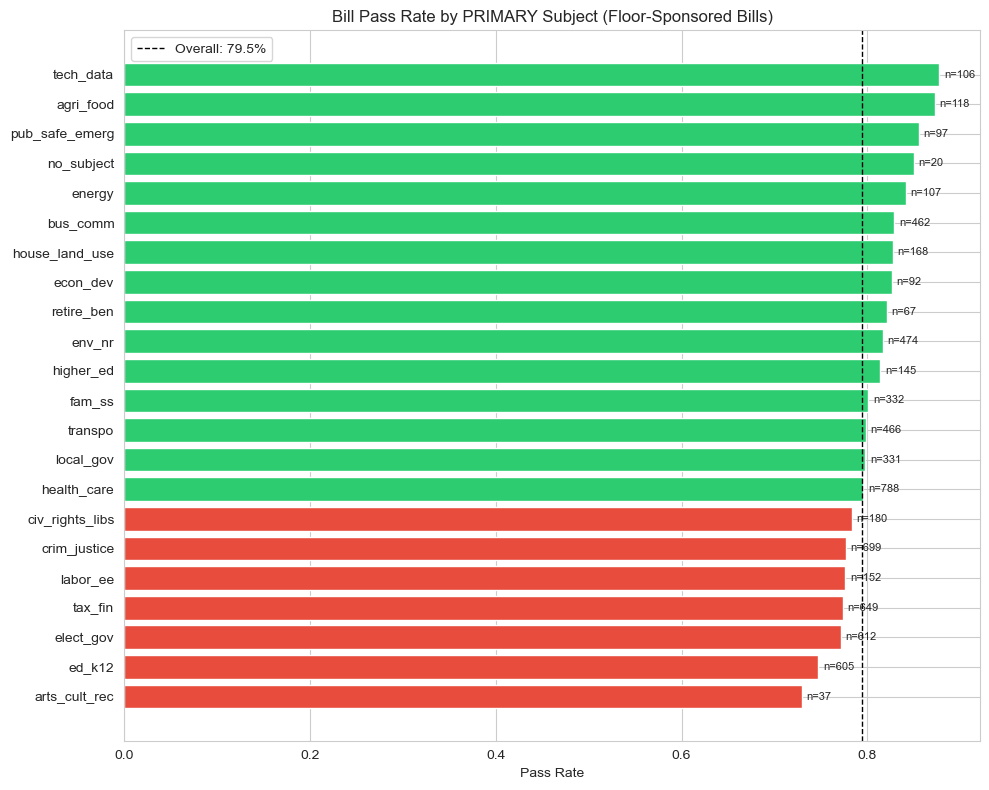

In [11]:
pass_rates = {}
for col in SUBJECT_COLS:
    subset = df[df[col] == 1]
    if len(subset) > 0:
        pass_rates[col] = {'pass_rate': subset['passed'].mean(), 'count': len(subset)}

pr_df = pd.DataFrame(pass_rates).T.sort_values('pass_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if r > df['passed'].mean() else '#e74c3c' for r in pr_df['pass_rate']]
bars = ax.barh(pr_df.index, pr_df['pass_rate'], color=colors, edgecolor='white')
ax.axvline(df['passed'].mean(), color='black', linestyle='--', linewidth=1,
           label=f'Overall: {df["passed"].mean():.1%}')
ax.set_xlabel('Pass Rate')
ax.set_title('Bill Pass Rate by PRIMARY Subject (Floor-Sponsored Bills)')
ax.legend()

for bar, (_, row) in zip(bars, pr_df.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={int(row["count"])}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

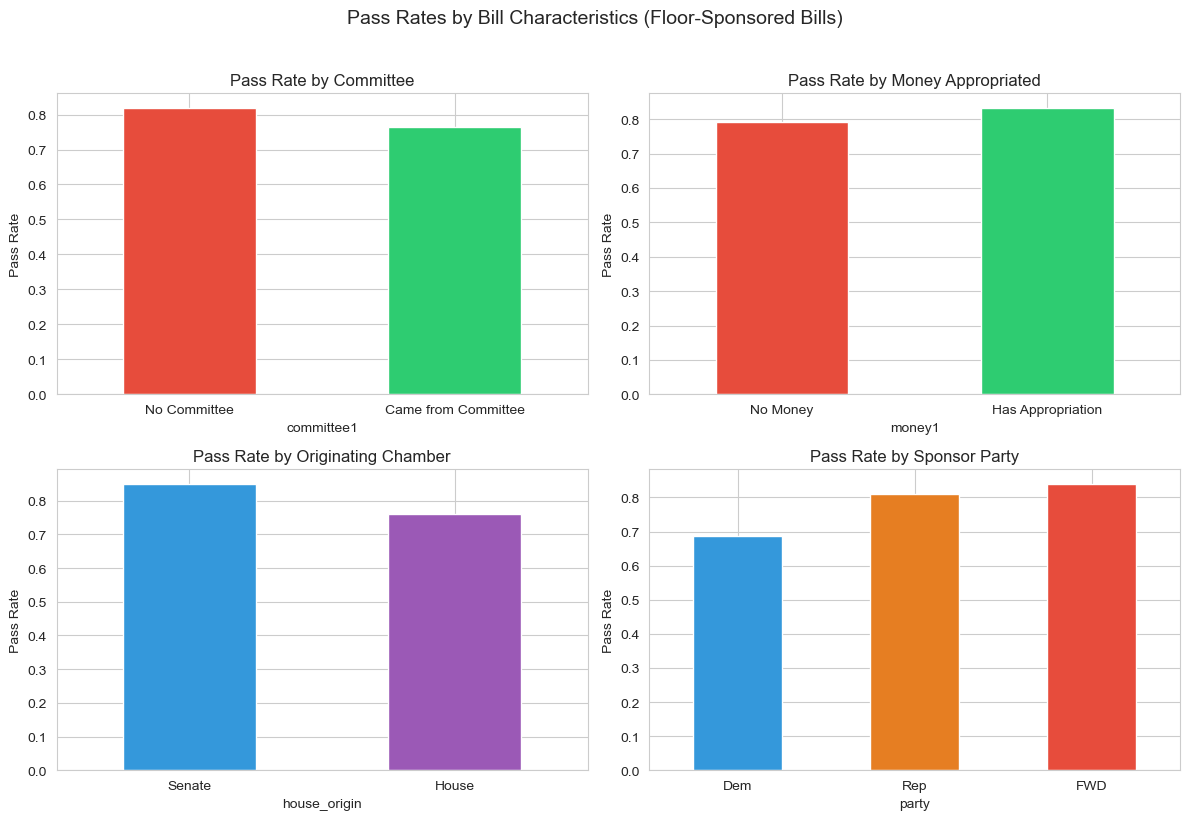

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
df.groupby('committee1')['passed'].mean().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Pass Rate by Committee')
ax.set_xticklabels(['No Committee', 'Came from Committee'], rotation=0)
ax.set_ylabel('Pass Rate')

ax = axes[0, 1]
df.groupby('money1')['passed'].mean().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Pass Rate by Money Appropriated')
ax.set_xticklabels(['No Money', 'Has Appropriation'], rotation=0)
ax.set_ylabel('Pass Rate')

ax = axes[1, 0]
df.groupby('house_origin')['passed'].mean().plot(kind='bar', ax=ax, color=['#3498db', '#9b59b6'])
ax.set_title('Pass Rate by Originating Chamber')
ax.set_xticklabels(['Senate', 'House'], rotation=0)
ax.set_ylabel('Pass Rate')

ax = axes[1, 1]
party_pass = df.groupby('party')['passed'].mean().sort_values()
party_pass.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22', '#e74c3c'])
ax.set_title('Pass Rate by Sponsor Party')
ax.set_ylabel('Pass Rate')
ax.set_xticklabels(party_pass.index, rotation=0)

plt.suptitle('Pass Rates by Bill Characteristics (Floor-Sponsored Bills)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

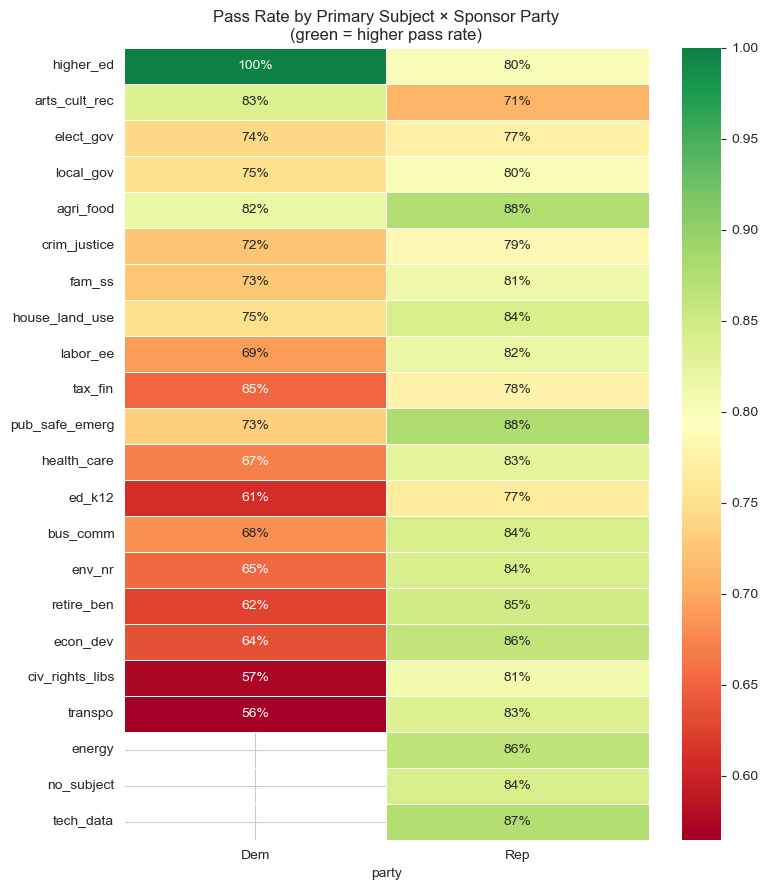

Largest Republican advantage (Rep - Dem pass rate):
subject
transpo            0.269642
civ_rights_libs    0.238698
econ_dev           0.224396
retire_ben         0.222458
env_nr             0.184634

Largest Democrat advantage:
subject
higher_ed       -0.198529
arts_cult_rec   -0.123656
elect_gov        0.026688
local_gov        0.049331
agri_food        0.059177


In [14]:
subject_party = []
for col in SUBJECT_COLS:
    for party in ['Rep', 'Dem']:
        subset = df[(df[col] == 1) & (df['party'] == party)]
        if len(subset) > 5:
            subject_party.append({'subject': col, 'party': party,
                                  'pass_rate': subset['passed'].mean(), 'n': len(subset)})

sp_df = pd.DataFrame(subject_party)
sp_pivot = sp_df.pivot(index='subject', columns='party', values='pass_rate')
sp_pivot['gap'] = sp_pivot['Rep'] - sp_pivot['Dem']
sp_pivot = sp_pivot.sort_values('gap')

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(sp_pivot[['Dem', 'Rep']], annot=True, fmt='.0%', cmap='RdYlGn',
            center=df['passed'].mean(), linewidths=0.5, ax=ax)
ax.set_title('Pass Rate by Primary Subject × Sponsor Party\n(green = higher pass rate)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("Largest Republican advantage (Rep - Dem pass rate):")
print(sp_pivot['gap'].sort_values(ascending=False).head(5).to_string())
print("\nLargest Democrat advantage:")
print(sp_pivot['gap'].sort_values().head(5).to_string())

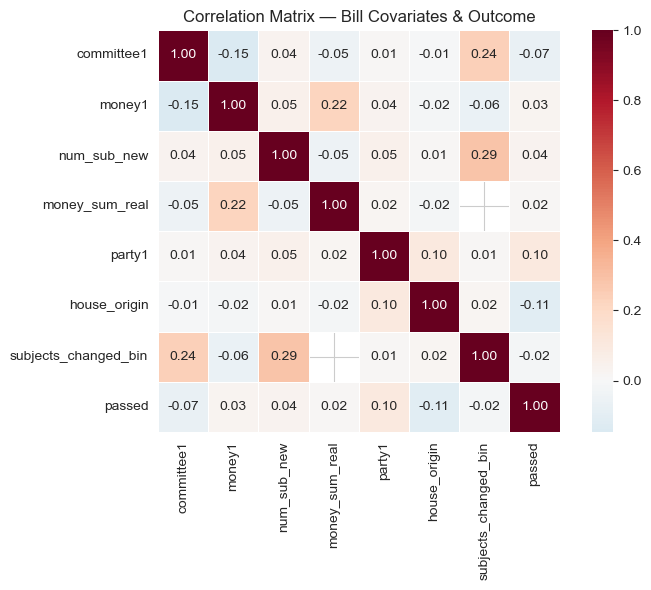

In [15]:
BILL_COVARIATES = ['committee1', 'money1', 'num_sub_new', 'money_sum_real', 'party1']

corr_cols = BILL_COVARIATES + ['house_origin', 'subjects_changed_bin', 'passed']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Bill Covariates & Outcome')
plt.tight_layout()
plt.show()

## Analysis Methodology

### Method 1: Logistic regression

This method is to answer the questions "What aspects of a bill influence it's passage/outcome?" and "Do economic indicators influence what policy is passed?". We chose logistic regression due to the binary nature of our desired dependent variables, as well as the probabilistic nature of our research questions (another way to phrase our questions is "How does a bill's characteristics affect the *probability* of bill passage?").

Our first model measures bill passage as a function of various bill characteristics. The coefficients of this and all subsequent logistic regression models are log-odds ratios of the probability of a bill passes into law.

In [22]:
import statsmodels.formula.api as sm

df_bills = pd.read_csv("df_bills.csv")
bills_logit1 = sm.logit(formula = 'passed ~ party1 + chamber1 + committee1 + cospon1 + log_money_real + ed_k12 + crim_justice + elect_gov + tech_data + env_nr + health_care',
                       data = df_bills,).fit()
print(bills_logit1.summary())

         Current function value: 0.628942
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 passed   No. Observations:                 6867
Model:                          Logit   Df Residuals:                     6855
Method:                           MLE   Df Model:                           11
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                 0.04702
Time:                        20:15:31   Log-Likelihood:                -4318.9
converged:                      False   LL-Null:                       -4532.0
Covariance Type:            nonrobust   LLR p-value:                 1.694e-84
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.3139      0.076      4.135      0.000       0.165       0.463
party1             0.8442      0.068     12.363      

C:\Users\gabri\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Overall, this model is not very powerful or predictive of bill success: it's Pseudo-$R^2$ is 0.0469, or it explains only 4.7% of the variation in the bill passage variable. Looking at the p-values of the covariates, "party1", "chamber1", "committee1", 'log_money_real", and "ed_k12" are all statistically significant. Party status has a positive coefficient of 0.8442, meaning that, all else equal, bills sponsored by a majority party member (Republican) have $e^(0.8442)$ or 2.33 times higher odds of passing than minority party affiliated bills. This finding reflects the Republican supermajority of the Utah Legislature and the power this fact gives the party. Committee affiliation also has a positive coefficient of 0.2255, meaning that bills associated with a committee have 1.25 times higher odds of passing. This conflicts with our exploratory analysis that found a drop in passage between bills that were affiliated with a committee and those not.

Chamber of origin has a negative coefficient of -0.8259, meaning that bills starting in the House have 0.44 odds of passing than bills starting in the Senate. This finding can be attributed to the difference in lawmaking approaches between the chambers; the Senate believe their chamber to be more methodical in its bill proposals, putting its focus on bill quality over bill quantity. Thus, senators may expend extra efforts on a few important bills that are ready to become law and pass the initial scrutiny of the Senate rather than produce a lot of lessesr bills. This theory is supported by the number of bills in each chamber: the House had 4190 bills with a 76.10\% pass rate, while the Senate only had 2540 bills but an 85\% pass rate.

The log appropriations of a bill have a positive effect on bill passage, where a log unit increase in money appropriated increases the odds of passage 1.09 times. The positive relationship is counterintuitive, since funding and money usually draws increased scrutiny and debate, but may be an artifact of the amount of budget bills captured in this variable. Budget appropriations are passed every year to fund state services and agencies, and if a budget bill does not pass that department's services are stopped. Thus, there is a signficant obstacle blocking the failure of a budget bill, which may influence the relationship of money appropriated and bill outcome.

Finally, the only subject group that was statistically significant in this model was K-12 education, which had a negative relationship with bill passage. This means that bills relating to K-12 education have significantly lower odds of passing than other subjects, all else equal. This finding has interesting implications regarding the Utah Legislature's policy priorities: this may mean that the legislature is divided on best K-12 policy priorities and thus strike down most bills in this area.

This next logit model includes our economic indicators to determine if the Utah economy influences bill passage.

In [24]:

bills_logit2 = sm.logit(formula = 'passed ~ party1 + chamber1 + committee1 + cospon1 + log_money_real + ed_k12 + crim_justice + elect_gov + tech_data + env_nr + health_care + real_gdp + poverty_rate + rental_vacancy_rate',
                       data = df_bills,).fit()
print(bills_logit2.summary())

         Current function value: 0.617948
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 passed   No. Observations:                 6867
Model:                          Logit   Df Residuals:                     6852
Method:                           MLE   Df Model:                           14
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                 0.06367
Time:                        20:38:05   Log-Likelihood:                -4243.5
converged:                      False   LL-Null:                       -4532.0
Covariance Type:            nonrobust   LLR p-value:                3.865e-114
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.7320      0.599      2.891      0.004       0.558       2.906
party1                  0.8642      0.

C:\Users\gabri\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The goodness-of-fit of this model is better than the previous model: it's Psuedo-$R^2$ is 0.0637, or 6.37% of the variation in bill passage is explained by this model. While an improvement, this model still is not a powerful predictor of bill passage.

All variables that were significant in the previous model remained significant, with the additions of all three economic indicators. The economic indicator's significance counter our observations in "Data Exploration", which found little correlation between the session pass rate and each indicator. Our logistic regression may be flawed due to the structure of the dataset: to make sure every bill had an economic indicator observation, we assigned the economic indicator value for the year of that bill's general session. This assignment of values, however, convinces the logit regression that each poverty rate, for example, for a bill is an independent observation unique to just that bill, which it is not (it is an independent observation for each *session*). This influences the standard errors of the coefficent estimates and will lead to Type I errors, saying a coefficient is statistically significant when it is not. This limitation in our data makes it difficult to say whether the state's economy influences a bill success rate. However, the decision tree classifier provides more insights into this question.

### Method 2: Decision Trees and Random Forest

We also fit a random forest classifier to predict bill passage, using the same set of bill-level features as the logistic regression models. Random forests are well-suited for this task because they capture non-linear relationships and interactions between features that logistic regression cannot, and their feature importance scores provide an interpretable ranking of which bill characteristics most influence the model's predictions. Like the logistic regression models, we used `class_weight='balanced'` to address the ~80/20 class imbalance, and evaluated performance using 5-fold stratified cross-validation.

The model achieved a balanced accuracy of 0.601 and a ROC-AUC of 0.633, which is comparable to the best logistic regression model. Failed-class recall was 0.589, meaning the model correctly identified roughly 59% of bills that ultimately did not pass. However, failed-class precision was only 0.24, meaning that when the model predicted a bill would fail, it was correct less than a quarter of the time. The confusion matrix reflects this: while the model correctly classified 2,686 passed bills, it misclassified 2,661 — nearly half of all passed bills flagged as failures. This tradeoff is a direct consequence of class weighting, which forces the model to be more aggressive about predicting failure at the cost of precision. It also reflects a more fundamental limitation: bill failure is difficult to predict from structural features alone, as many of the factors that kill a bill — political timing, lobbying pressure, internal negotiations — are not captured in this dataset.

The feature importance plot reveals that `house_origin`, `party1`, and `committee1` are the strongest predictors of bill outcome, followed distantly by `num_sub_new` and `money_sum_real`. This is consistent with the coefficient signs we observed in the logistic regression. Subject group features generally ranked lower in importance, suggesting that the structural characteristics of a bill — which chamber it originates in, who sponsors it, and whether it has a committee assignment — are more predictive of passage than its policy domain alone.

As with the logistic regression, the economic indicators were excluded from this model due to the dataset limitation described above: because every bill in a given session shares the same indicator value, including them would inflate their apparent importance and produce misleading results.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, make_scorer, recall_score, precision_score

SUBJECT_COLS = [
    'agri_food', 'arts_cult_rec', 'bus_comm', 'civ_rights_libs', 'crim_justice',
    'econ_dev', 'ed_k12', 'elect_gov', 'energy', 'env_nr', 'fam_ss',
    'health_care', 'higher_ed', 'house_land_use', 'labor_ee', 'local_gov',
    'no_subject', 'pub_safe_emerg', 'retire_ben', 'tax_fin', 'tech_data', 'transpo'
]
BILL_COVARIATES = ['committee1', 'money1', 'num_sub_new', 'money_sum_real', 'party1']

feature_cols = SUBJECT_COLS + BILL_COVARIATES + ['house_origin', 'subjects_changed_bin']
y_full = df['passed'].copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_failed = {
    'accuracy': 'accuracy',
    'balanced_acc': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'recall_failed': make_scorer(recall_score, pos_label=0),
    'precision_failed': make_scorer(precision_score, pos_label=0, zero_division=0),
    'recall_passed': make_scorer(recall_score, pos_label=1),
}

rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                             random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(df[feature_cols], y_full)

cv_rf = cross_validate(rf, df[feature_cols], y_full, cv=cv, scoring=scoring_failed)
print("Random Forest 5-Fold CV (class-weighted):")
print(f"  Accuracy:         {cv_rf['test_accuracy'].mean():.3f} ± {cv_rf['test_accuracy'].std():.3f}")
print(f"  Balanced Acc:     {cv_rf['test_balanced_acc'].mean():.3f} ± {cv_rf['test_balanced_acc'].std():.3f}")
print(f"  ROC-AUC:          {cv_rf['test_roc_auc'].mean():.3f} ± {cv_rf['test_roc_auc'].std():.3f}")
print(f"  Failed Recall:    {cv_rf['test_recall_failed'].mean():.3f} ± {cv_rf['test_recall_failed'].std():.3f}")
print(f"  Failed Precision: {cv_rf['test_precision_failed'].mean():.3f} ± {cv_rf['test_precision_failed'].std():.3f}")
print(f"  Passed Recall:    {cv_rf['test_recall_passed'].mean():.3f} ± {cv_rf['test_recall_passed'].std():.3f}")

Random Forest 5-Fold CV (class-weighted):
  Accuracy:         0.609 ± 0.020
  Balanced Acc:     0.601 ± 0.011
  ROC-AUC:          0.633 ± 0.014
  Failed Recall:    0.589 ± 0.033
  Failed Precision: 0.283 ± 0.010
  Passed Recall:    0.614 ± 0.031


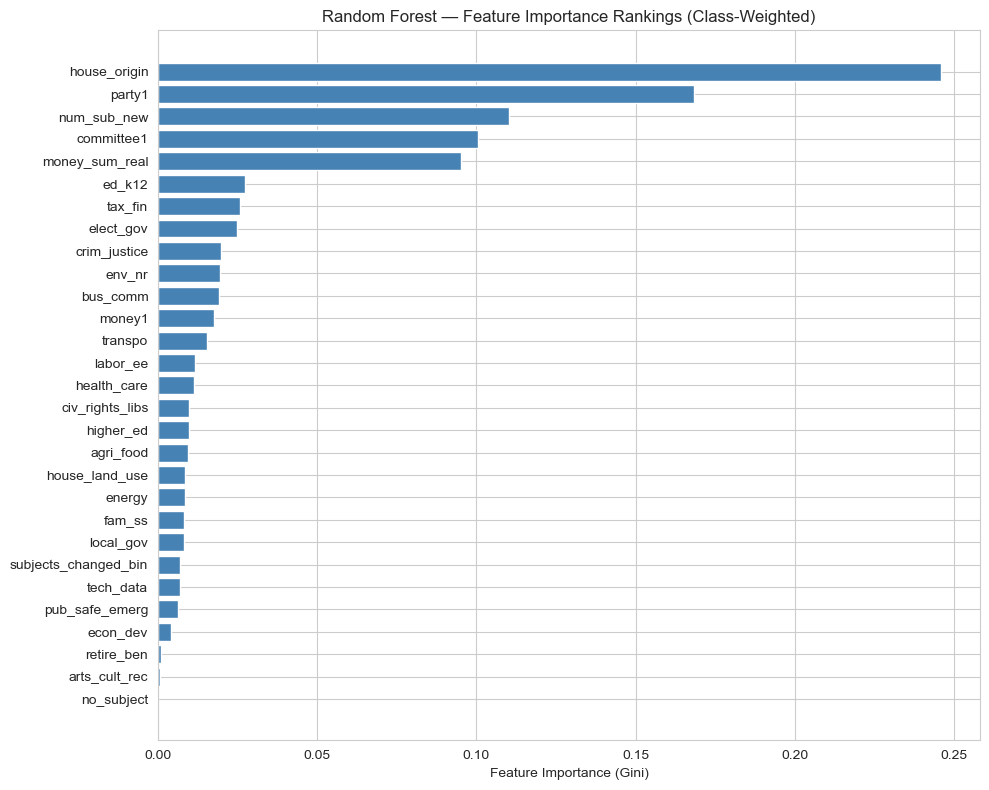

In [21]:
imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importance Rankings (Class-Weighted)')
plt.tight_layout()
plt.show()

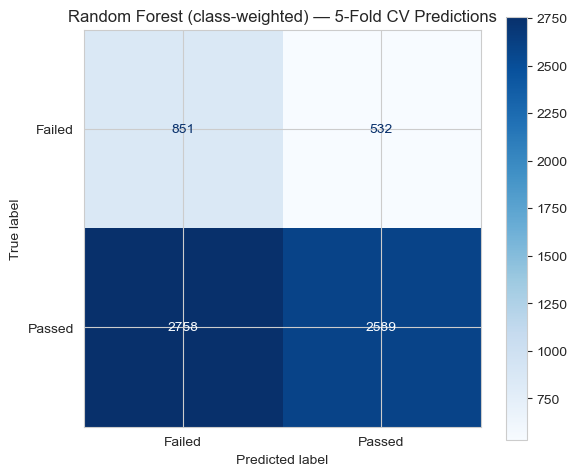

              precision    recall  f1-score   support

      Failed       0.24      0.62      0.34      1383
      Passed       0.83      0.48      0.61      5347

    accuracy                           0.51      6730
   macro avg       0.53      0.55      0.48      6730
weighted avg       0.71      0.51      0.56      6730



In [22]:
from sklearn.model_selection import cross_val_predict

y_pred_rf = cross_val_predict(
    RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                           random_state=42, n_jobs=-1, class_weight='balanced'),
    df[feature_cols], y_full, cv=5
)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_full, y_pred_rf,
                                         display_labels=['Failed', 'Passed'],
                                         cmap='Blues', ax=ax)
ax.set_title('Random Forest (class-weighted) — 5-Fold CV Predictions')
plt.tight_layout()
plt.show()

print(classification_report(y_full, y_pred_rf, target_names=['Failed', 'Passed']))

## Conclusion

**LUCY PLEASE WRITE BLESS YOU**